## Semaine 1 :

- cadrage 
- repo 
- smoke_test


## Semaine 2 : 

**Objectif** : Établir les performances de base avec le modèle MedGemma 4B sans aucun entraînement, uniquement via du prompting structuré sur 20 cas (Smoke Test).

In [6]:
from dotenv import load_dotenv
import pandas as pd 
import json
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, BitsAndBytesConfig
from PIL import Image
from huggingface_hub import login
import os
import collections
import shutil
import pydicom
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from torch.utils.data import Dataset
from torch.optim import AdamW

In [8]:
df = pd.read_csv("smoke_Test/smoke_Test.csv")

### Chargement du modèle

In [7]:
load_dotenv()

HF_Token = os.getenv("HF_TOKEN")

login(token = HF_Token)

model_ID = "google/medgemma-1.5-4b-it"
print("Chargement du modèle en cours ...")

processor = AutoProcessor.from_pretrained(model_ID)

device = "cuda" if torch.cuda.is_available() else "cpu"

model = AutoModelForImageTextToText.from_pretrained(
    model_ID, 
    dtype = torch.bfloat16, 
    device_map = "auto"          
)

print(f"Modèle chargé avec succès sur : {device}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Chargement du modèle en cours ...


Loading weights: 100%|██████████| 883/883 [00:00<00:00, 2768.87it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Modèle chargé avec succès sur : cuda


In [8]:
from huggingface_hub import HfApi

api = HfApi()
infos = api.whoami()

print(f"Connecté en tant que : {infos['name']}")
print("Droits du token :")
for permission in infos['auth']['accessToken']['fineGrained']['scoped']:
    print(f"- {permission}")

Connecté en tant que : Doriped
Droits du token :
- {'entity': {'_id': '6a318331e5c620c802e7f475', 'type': 'user', 'name': 'Doriped'}, 'permissions': ['repo.content.read', 'repo.access.read', 'repo.write']}


### Conception du Prompt Base line

In [ ]:
def creer_Prompt():
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},   # placeholder géré par le processor
                {
                    "type": "text",
                    "text": (
                        "Tu es un assistant radiologue virtuel expert. "
                        "Ton rôle est d'analyser des radiographies thoraciques frontales "
                        "dans un but strictement pédagogique.\n\n"
                        "TA TÂCHE :\n"
                        "Analyse l'image fournie et classe-la UNIQUEMENT parmi l'une de ces 3 catégories :\n"
                        "1. \"normal\" : Poumons clairs, aucune anomalie visible.\n"
                        "2. \"suspected_opacity\" : Présence d'opacités, suspicion de pathologie.\n"
                        "3. \"uncertain\" : Qualité d'image insuffisante ou anomalies ne permettant pas de trancher.\n\n"
                        "CONTRAINTE DE SORTIE :\n"
                        "Tu dois formater ta réponse STRICTEMENT sous la forme d'un objet JSON valide. "
                        "Ne génère aucun autre texte, ni avant, ni après les accolades. "
                        "N'utilise pas de balises markdown.\n\n"
                        "Gabarit JSON à respecter à la lettre :\n"
                        "{\n"
                        "  \"image_quality\": \"<Choisis: bonne, moyenne, ou mauvaise>\",\n"
                        "  \"predicted_class\": \"<Choisis: normal, suspected_opacity, ou uncertain>\",\n"
                        "  \"confidence\": <Donne un score numérique entre 0.00 et 1.00>,\n"
                        "  \"visual_evidence\": \"<Description factuelle des signes visuels observés>\",\n"
                        "  \"justification\": \"<Ton raisonnement clinique court en 1 ou 2 phrases>\",\n"
                        "  \"limitations\": \"<Facteurs limitants éventuels, ex: mauvaise qualité, positionnement>\",\n"
                        "  \"warning\": \"Avertissement: Incertitude IA, nécessite une relecture médicale\"\n"
                        "}"
                    )
                }
            ]
        }
    ]
    return messages

### Extraction de la réponse souhaitée

In [3]:
def extraire_json(reponse_brute):
    if "<unused95>" in reponse_brute:
        partie_apres_thinking = reponse_brute.split("<unused95>")[-1]
    else:
        partie_apres_thinking = reponse_brute

    if "```json" in partie_apres_thinking:
        return partie_apres_thinking.split("```json")[-1].split("```")[0].strip()
    elif "{" in partie_apres_thinking:
        return partie_apres_thinking[partie_apres_thinking.index("{"):].strip()
    else:
        return partie_apres_thinking.strip()

### Exécution sur le smoke test

In [ ]:
dossier_Images = "smoke_Test/images/"

resultats_Baseline = []

print(f"Lancement du Smoke Test sur {len(df)} patients...")

for index, row in df.iterrows():
    patient_ID = row['patientId']

    nom_Fichier_Image = patient_ID + ".png"
    chemin_Image = dossier_Images + nom_Fichier_Image

    print(f"\n[{index + 1}/{len(df)}] Analyse de l'image : {nom_Fichier_Image}...")

    try:
        image = Image.open(chemin_Image).convert("RGB")
        messages = creer_Prompt_CoT()

        messages[0]["content"][0]["image"] = image

        inputs = processor.apply_chat_template(
            messages,
            add_generation_prompt = True,
            tokenize = True,
            return_dict = True,
            return_tensors = "pt"
        ).to(model.device, dtype = torch.bfloat16)

        input_len = inputs["input_ids"].shape[-1]

        with torch.inference_mode():
            outputs = model.generate(**inputs, max_new_tokens = 1200, do_sample = False)
            outputs = outputs[0][input_len:]

        reponse_brute = processor.decode(outputs, skip_special_tokens = True)
        reponse_json = extraire_json(reponse_brute)

        resultats_Baseline.append({
            "patientId": patient_ID,
            "class_origine": row['classe_projet'],
            "qualite": row['qualite'],
            "reponse_ia_brute": reponse_json
        })

    except Exception as e:
        print(f"Erreur sur ce patient : {e}")
        resultats_Baseline.append({
            "patientId": patient_ID,
            "class_origine": row['classe_projet'],
            "qualite": row['qualite'],
            "reponse_ia_brute": f"ERREUR: {e}"
        })

print("\nSauvegarde des résultats en cours...")
df_resultats = pd.DataFrame(resultats_Baseline)
df_resultats.to_csv("CSV_Resultats/resultats_CoT_S2.csv", index = False)

print("SMOKE TEST TERMINÉ ! Les résultats sont enregistrés dans 'resultats_Baseline_S2.csv'.")
        

[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


Lancement du Smoke Test sur 20 patients...

[1/20] Analyse de l'image : 0004cfab-14fd-4e49-80ba-63a80b6bddd6.png...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



[2/20] Analyse de l'image : 00313ee0-9eaa-42f4-b0ab-c148ed3241cd.png...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...


[18/20] Analyse de l'image : 01a6eaa6-222f-4ea8-9874-bbd89dc1a1ce.png...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



[19/20] Analyse de l'image : 01a7353d-25bb-4ff8-916b-f50dd541dccf.png...


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



[20/20] Analyse de l'image : 01aad2a6-3b93-45e3-bf37-2d73348cb6fc.png...

Sauvegarde des résultats en cours...
SMOKE TEST TERMINÉ ! Les résultats sont enregistrés dans 'resultats_Baseline_S2.csv'.


### Comparaison résultat Baseline / Data

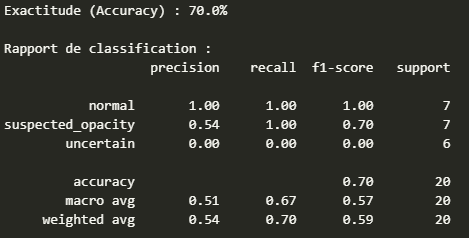

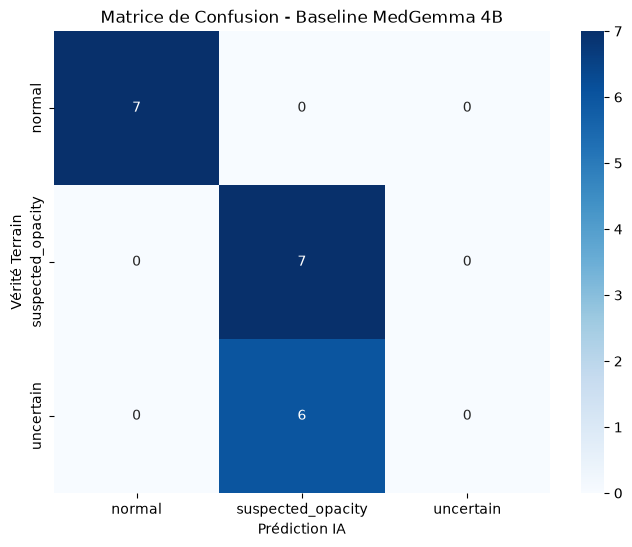

### Bilan Synthétique de la Baseline

**1. Validation Technique :**
- Validité du format JSON : 100 % (20/20)
- 100% des réponses possèdent un avertissement
- 0 hallucination
- Latence de ~3min

**2. Évaluation des Performances Médicales** 

* Exactitude (Accuracy) Globale : 70.0 %
* Macro F1-Score : 0.57 (indique un déséquilibre dans la maîtrise des différentes classes).

**3. Analyse des Erreurs :** 

Le "Biais de Prudence" : L'IA s'est trompée uniquement sur les 6 cas "Incertains" (tous classés à tort en *suspected_opacity*). Face à des images floues ou dégradées, le modèle préfère surestimer le risque plutôt que d'assumer son incertitude.

## Semaine 3

**Test de variantes de notre prompt baseline afin d'essayer d'améliorer les résultats**

### 1er prompt :

On ajoute une règle explicite concernant les images floues pour tenter de "casser" le biais de prudence de l'IA.

In [4]:
def creer_Prompt_FewShot():
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": (
                        "Tu es un assistant radiologue virtuel expert. "
                        "Ton rôle est d'analyser des radiographies thoraciques frontales.\n\n"
                        "TA TÂCHE :\n"
                        "Analyse l'image fournie et classe-la UNIQUEMENT parmi l'une de ces 3 catégories :\n"
                        "1. \"normal\" : Poumons clairs, aucune anomalie visible.\n"
                        "2. \"suspected_opacity\" : Présence d'opacités, suspicion de pathologie.\n"
                        "3. \"uncertain\" : Qualité d'image insuffisante ou anomalies ne permettant pas de trancher.\n\n"
                        "RÈGLE ET EXEMPLE IMPORTANT :\n"
                        "Si la radiographie est trop floue, que des câbles/tubes masquent les poumons, "
                        "ou que tu estimes la qualité comme 'mauvaise' ou 'moyenne' au point de douter, "
                        "tu DOIS utiliser la classe \"uncertain\". Ne choisis \"suspected_opacity\" "
                        "que si tu vois une vraie opacité claire sur une image lisible.\n\n"
                        "CONTRAINTE DE SORTIE :\n"
                        "Génère UNIQUEMENT un objet JSON valide, sans markdown, selon ce gabarit :\n"
                        "{\n"
                        "  \"image_quality\": \"<Choisis: bonne, moyenne, ou mauvaise>\",\n"
                        "  \"predicted_class\": \"<Choisis: normal, suspected_opacity, ou uncertain>\",\n"
                        "  \"confidence\": <Score entre 0.00 et 1.00>,\n"
                        "  \"visual_evidence\": \"<Signes observés>\",\n"
                        "  \"justification\": \"<Raisonnement clinique>\",\n"
                        "  \"limitations\": \"<Facteurs limitants éventuels>\",\n"
                        "  \"warning\": \"Avertissement: Incertitude IA, nécessite une relecture médicale\"\n"
                        "}"
                    )
                }
            ]
        }
    ]
    return messages

### Bilan Synthétique du Prompt Few-Shot

**1. Validation Technique :**
- Validité du format JSON : 100 % (20/20)
- 100% des réponses possèdent un avertissement
- 0 hallucination
- Latence de ~3min

**2. Évaluation des Performances Médicales** 

* Exactitude (Accuracy) Globale : 60.0 % 
* Macro F1-Score : 0.57

**3. Analyse des Erreurs :** 

L'IA a bien appliqué la nouvelle consigne et a enfin réussi à utiliser la classe uncertain (1 cas correctement détecté). Cependant, cela a engendré un effet collatéral dangereux : sur 3 patients présentant de véritables opacités (suspected_opacity) l'IA a prit peur et les as classés à tort comme uncertain.

### 2eme prompt :

On inverse l'ordre des clés dans la réponse. On force l'IA a donner la justification avant la conclusion (la classe) dans le but qu'elle commette moins d'erreur de précipitation.

In [4]:
def creer_Prompt_CoT():
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image"},
                {
                    "type": "text",
                    "text": (
                        "Tu es un assistant radiologue virtuel expert. "
                        "Ton rôle est d'analyser des radiographies thoraciques frontales.\n\n"
                        "TA TÂCHE :\n"
                        "Analyse l'image fournie et classe-la UNIQUEMENT parmi l'une de ces 3 catégories : "
                        "\"normal\", \"suspected_opacity\", ou \"uncertain\".\n\n"
                        "CONTRAINTE DE SORTIE (Raisonnement pas à pas) :\n"
                        "Pour éviter les erreurs, tu dois d'abord évaluer la qualité et décrire ce que tu vois AVANT de donner ta conclusion. "
                        "Génère UNIQUEMENT un objet JSON valide, sans markdown, selon cet ordre exact :\n"
                        "{\n"
                        "  \"image_quality\": \"<Choisis: bonne, moyenne, ou mauvaise>\",\n"
                        "  \"limitations\": \"<Identifie d'abord si la radio est difficile à lire, ex: câbles, flou>\",\n"
                        "  \"visual_evidence\": \"<Description factuelle des signes visuels>\",\n"
                        "  \"justification\": \"<Ton raisonnement basé sur les éléments ci-dessus>\",\n"
                        "  \"predicted_class\": \"<Choisis ENFIN: normal, suspected_opacity, ou uncertain>\",\n"
                        "  \"confidence\": <Score entre 0.00 et 1.00>,\n"
                        "  \"warning\": \"Avertissement: Incertitude IA, nécessite une relecture médicale\"\n"
                        "}"
                    )
                }
            ]
        }
    ]
    return messages

### Bilan Synthétique du prompt Chain of thought

**1. Validation Technique :**
- Validité du format JSON : 100 % (20/20)
- 100% des réponses possèdent un avertissement
- 0 hallucination
- Latence de ~3min

**2. Évaluation des Performances Médicales** 

* Exactitude (Accuracy) Globale : 70.0 %
* Macro F1-Score : 0.57

**3. Analyse des Erreurs :** 

Même résultat que pour la baseline.

### Tableau de comparaison de nos prompts

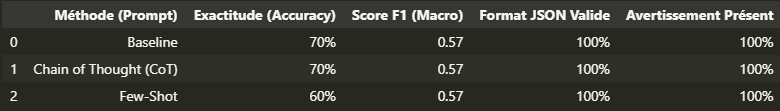

### Choix du prompt pour la suite

Nous retenons le prompt Chain of Thought (CoT) pour la suite du projet. Bien que son exactitude soit identique à la baseline (70 %), il force le modèle à détailler son raisonnement avant de conclure, ce qui est crucial pour un outil pédagogique. Cette structure rigide permet également de mieux stabiliser la langue de sortie et d'éliminer les générations aléatoires en anglais observées dans la baseline, garantissant ainsi une interface cohérente pour l'utilisateur final.

## Semaine 4

### Test de stabilité (auto-cohérence)

Le garde-fou littéral du brief (confidence < 0.60 ou qualité "mauvaise") ne rattrape aucun
des 6 cas `uncertain` : le modèle est confiant à tort, pas hésitant. On teste ici une autre
piste, sans entraînement : relancer chaque image plusieurs fois avec `do_sample=True` pour
voir si les cas ambigus produisent des réponses moins stables que les cas nets.

In [9]:
df_uncertain = df[df['classe_projet'] == 'uncertain']
df_normal = df[df['classe_projet'] == 'normal'].sample(3, random_state=42)
df_opacity = df[df['classe_projet'] == 'suspected_opacity'].sample(3, random_state=42)
df_test = pd.concat([df_uncertain, df_normal, df_opacity]).reset_index(drop=True)
print(f"{len(df_test)} cas sélectionnés")

12 cas sélectionnés


In [ ]:
N_SAMPLES = 3
resultats_stabilite = []

dossier_Images = "smoke_Test/images/"

for index, row in df_test.iterrows():
    patient_ID = row['patientId']
    chemin_Image = dossier_Images + patient_ID + ".png"
    print(f"\n[{index+1}/{len(df_test)}] {patient_ID} (vérité: {row['classe_projet']})")

    predictions = []
    for s in range(N_SAMPLES):
        try:
            image = Image.open(chemin_Image).convert("RGB")
            messages = creer_Prompt_CoT()
            messages[0]["content"][0]["image"] = image

            inputs = processor.apply_chat_template(
                messages, add_generation_prompt=True, tokenize=True,
                return_dict=True, return_tensors="pt"
            ).to(model.device, dtype=torch.bfloat16)

            input_len = inputs["input_ids"].shape[-1]
            with torch.inference_mode():
                outputs = model.generate(**inputs, max_new_tokens=1200,
                                          do_sample=True, temperature=0.7)
                outputs = outputs[0][input_len:]

            reponse_brute = processor.decode(outputs, skip_special_tokens=True)
            classe = json.loads(extraire_json(reponse_brute)).get("predicted_class")
            predictions.append(classe)
            print(f"  essai {s+1}: {classe}")
        except Exception as e:
            print(f"  erreur essai {s+1}: {e}")
            predictions.append("ERREUR")

    vote = collections.Counter(predictions)
    classe_maj, n_maj = vote.most_common(1)[0]
    resultats_stabilite.append({
        "patientId": patient_ID,
        "class_origine": row['classe_projet'],
        "predictions": predictions,
        "stable": n_maj == N_SAMPLES
    })

df_stabilite = pd.DataFrame(resultats_stabilite)
df_stabilite.to_csv("CSV_Resultats/test_stabilite_S4.csv", index=False)
print(df_stabilite[['class_origine','predictions','stable']].to_string())

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.



[1/12] 0004cfab-14fd-4e49-80ba-63a80b6bddd6 (vérité: uncertain)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  essai 1: suspected_opacity


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

  essai 3: suspected_opacity

[12/12] 01a6eaa6-222f-4ea8-9874-bbd89dc1a1ce (vérité: suspected_opacity)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  essai 1: suspected_opacity


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


  essai 2: suspected_opacity
  essai 3: suspected_opacity
        class_origine                                                predictions  stable
0           uncertain  [suspected_opacity, suspected_opacity, suspected_opacity]    True
1           uncertain  [suspected_opacity, suspected_opacity, suspected_opacity]    True
2           uncertain  [suspected_opacity, suspected_opacity, suspected_opacity]    True
3           uncertain  [suspected_opacity, suspected_opacity, suspected_opacity]    True
4           uncertain             [ERREUR, suspected_opacity, suspected_opacity]   False
5           uncertain  [suspected_opacity, suspected_opacity, suspected_opacity]    True
6              normal                                   [normal, normal, normal]    True
7              normal                                   [normal, normal, normal]    True
8              normal                                   [normal, normal, normal]    True
9   suspected_opacity  [suspected_opacity, suspected

In [12]:
print(df_stabilite.groupby('class_origine')['stable'].mean())

class_origine
normal               1.000000
suspected_opacity    0.666667
uncertain            0.833333
Name: stable, dtype: float64


### Bilan Synthétique : Test de stabilité (auto-cohérence)

**Hypothèse testée** : On teste si une instabilité entre plusieurs générations (do_sample=True, T=0.7) peut révéler
les cas réellement ambigus.

**Protocole** : 12 cas (6 uncertain, 3 normal, 3 suspected_opacity), 3 générations par cas.

**Résultat** :
- normal : 100% stable (3/3 unanimes)
- suspected_opacity : 66.7% stable (1 erreur technique sur 3 essais, pas un vrai désaccord)
- uncertain : 83.3% stable — y compris sur les cas où le modèle se trompe

**Conclusion** : Hypothèse invalidée. Le modèle reste stable même sur les cas ambigus :
l'instabilité inter-générations n'est pas un proxy fiable de l'incertitude ici. Ceci confirme
que le biais est ancré dans le raisonnement du modèle et non dans sa calibration de surface.

### Passage au fine-tuning (LoRA)

**Pourquoi maintenant et pas avant** : les deux pistes "sans entraînement" ont été testées et invalidées :

- le garde-fou littéral (confidence < 0.60 ou qualité mauvaise) ne rattrape aucun cas `uncertain` 
- l'auto-cohérence montre que le modèle est stable à 83% même quand il se trompe.

Les deux pointent vers la même conclusion : le biais n'est pas un problème de calibration de surface, il est **ancré dans les poids du modèle**. Le seul levier qui reste, sans changer de modèle de base, est de mettre à jour ces poids via un fine-tuning léger (LoRA).

### Création du Dataset de Développement

**Récupération de 150 cas pour création du csv**

In [ ]:
chemin_rsna = "rsna-pneumonia-detection-challenge/stage_2_detailed_class_info.csv"
df_rsna = pd.read_csv(chemin_rsna)

df_rsna = df_rsna.drop_duplicates(subset='patientId')

mapping = {
    'Normal': 'normal',
    'Lung Opacity': 'suspected_opacity',
    'No Lung Opacity / Not Normal': 'uncertain'
}

df_rsna['classe_projet'] = df_rsna['class'].map(mapping)

df_dev = df_rsna.groupby('classe_projet').sample(n=50, random_state=42).reset_index(drop=True)

df_dev = df_dev.sample(frac=1, random_state=42).reset_index(drop=True)

df_final = df_dev[['patientId', 'classe_projet']]

df_final.to_csv('dataset_Dev/dataset_dev.csv', index=False)
print("Fichier 'dataset_dev.csv' généré avec succès.")



Fichier 'dataset_dev_150.csv' généré avec succès.


**Récupération des radios correspondantes**

In [ ]:
df_dev = pd.read_csv('dataset_Dev/dataset_dev.csv')

dossier_source = "rsna-pneumonia-detection-challenge/stage_2_train_images"

dossier_destination = "dataset_Dev/images"

print(f"Début de la copie des images vers '{dossier_destination}'...")

images_copiees = 0
images_manquantes = 0

for patient_id in df_dev['patientId']:
    nom_fichier = f"{patient_id}.dcm"

    chemin_source = os.path.join(dossier_source, nom_fichier)
    chemin_dest = os.path.join(dossier_destination, nom_fichier)

    if os.path.exists(chemin_source):
        shutil.copy2(chemin_source, chemin_dest)
        images_copiees += 1
    else:
        print(f"Fichier introuvable : {chemin_source}")
        images_manquantes += 1

print(f"\nTerminé ! {images_copiees}/150 images ont été copiées.")
if images_manquantes > 0:
    print(f"Attention, {images_manquantes} images manquent à l'appel.")

Début de la copie des images vers 'dataset_Dev/images'...

Terminé ! 150/150 images ont été copiées.


Les radios de notre dataset de développement sont au format .dcm, format que medgemma ne peut pas lire. Il faut donc que l'on transforme ces images en image PIL lisible par le modèle.

### Formatage des images

In [5]:
def formatage_Image_dcm(image_dcm):
    dicom = pydicom.dcmread(image_dcm)

    pixels = dicom.pixel_array.astype(float)

    if dicom.PhotometricInterpretation == "MONOCHROME1":
        pixels = np.max(pixels) - pixels

    pixels = pixels - np.min(pixels)
    pixels = pixels / np.max(pixels)
    pixels = (pixels * 255).astype(np.uint8)

    image_pil = Image.fromarray(pixels)

    return image_pil

### Chargement du dataset de développement (150 cas, 50/classe)

In [6]:
DEV_CSV = "dataset_Dev/dataset_dev.csv"        
DEV_IMAGES = "dataset_Dev/images/"         

df_dev = pd.read_csv(DEV_CSV)
print(df_dev["classe_projet"].value_counts())

classe_projet
suspected_opacity    50
normal               50
uncertain            50
Name: count, dtype: int64


### Génération des réponses CoT sur le dataset de développement

In [9]:
resultats_Dev = []

for index, row in df_dev.iterrows():
    patient_ID = row["patientId"]
    chemin_Image = DEV_IMAGES + patient_ID + ".dcm"
    print(f"[{index + 1}/{len(df_dev)}] {patient_ID} (vérité: {row['classe_projet']})")

    try:
        image = formatage_Image_dcm(chemin_Image).convert("RGB")
        messages = creer_Prompt_CoT()
        messages[0]["content"][0]["image"] = image

        inputs = processor.apply_chat_template(
            messages, add_generation_prompt = True, tokenize = True,
            return_dict = True, return_tensors = "pt",
        ).to(model.device, dtype=torch.bfloat16)

        input_len = inputs["input_ids"].shape[-1]
        with torch.inference_mode():
            outputs = model.generate(**inputs, max_new_tokens = 1200, do_sample = False)
            outputs = outputs[0][input_len:]

        reponse_brute = processor.decode(outputs, skip_special_tokens=True)
        reponse_json = extraire_json(reponse_brute)

        resultats_Dev.append({
            "patientId": patient_ID,
            "class_origine": row["classe_projet"],
            "reponse_ia_brute": reponse_json,
        })

    except Exception as e:
        print(f"  Erreur : {e}")
        resultats_Dev.append({
            "patientId": patient_ID,
            "class_origine": row["classe_projet"],
            "reponse_ia_brute": f"ERREUR: {e}",
        })

    if (index + 1) % 10 == 0:
        pd.DataFrame(resultats_Dev).to_csv("resultats_CoT_dev.csv", index = False)

df_resultats_dev = pd.DataFrame(resultats_Dev)
df_resultats_dev.to_csv("resultats_CoT_dev.csv", index = False)
print("Terminé.")

[transformers] Deprecated: `processor.image_token` will switch from returning `tokenizer.image_token` to `tokenizer.boi_token` in v5.11.
[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[1/150] 32827da4-939c-46de-85db-a2d75cb0dfad (vérité: suspected_opacity)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[2/150] f363306d-1c02-4182-9118-17e28d66d265 (vérité: normal)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


...

[148/150] c1fd8229-6d44-4bde-8137-690092433542 (vérité: normal)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[149/150] af0a996a-d4a0-44c7-b316-72176ea9838b (vérité: suspected_opacity)


[transformers] Setting `pad_token_id` to `eos_token_id`:1 for open-end generation.


[150/150] 899fecd3-52be-4b08-aa2c-3f07ef981ba9 (vérité: uncertain)
Terminé.


### Bilan : baseline CoT sur le dataset de développement (150 cas)

In [7]:
classes_predites = []
for _, row in df_resultats_dev.iterrows():
    try:
        classes_predites.append(json.loads(row["reponse_ia_brute"]).get("predicted_class"))
    except (json.JSONDecodeError, TypeError):
        classes_predites.append("ERREUR_JSON")

df_resultats_dev["predicted_class"] = classes_predites
df_json_valide = df_resultats_dev[df_resultats_dev["predicted_class"] != "ERREUR_JSON"]

labels = ["normal", "suspected_opacity", "uncertain"]
print(f"JSON valide : {len(df_json_valide)}/{len(df_resultats_dev)} "
      f"({100*len(df_json_valide)/len(df_resultats_dev):.1f}%)\n")
print(classification_report(df_json_valide["class_origine"], df_json_valide["predicted_class"],
                             labels=labels, digits=3))
print("Matrice de confusion (lignes=vrai, colonnes=prédit,", labels, "):")
print(confusion_matrix(df_json_valide["class_origine"], df_json_valide["predicted_class"], labels=labels))

JSON valide : 148/150 (98.7%)

                   precision    recall  f1-score   support

           normal      0.804     0.837     0.820        49
suspected_opacity      0.510     0.980     0.671        50
        uncertain      0.000     0.000     0.000        49

         accuracy                          0.608       148
        macro avg      0.438     0.606     0.497       148
     weighted avg      0.439     0.608     0.498       148

Matrice de confusion (lignes=vrai, colonnes=prédit, ['normal', 'suspected_opacity', 'uncertain'] ):
[[41  8  0]
 [ 0 49  1]
 [10 39  0]]


**Résultat** :
- Accuracy : 0.608 — Macro-F1 : 0.497 (en net retrait par rapport aux 70% / 0.57 du smoke test : le volume plus large et plus représentatif révèle un score réel plus sévère)
- `normal` : précision 0.804, rappel 0.837 — correct
- `suspected_opacity` : précision 0.510, rappel 0.980 — le modèle y range presque tout, y compris à tort
- `uncertain` : précision 0.000, rappel 0.000 — **aucun des 49 cas valides n'est correctement classé** (39 envoyés en `suspected_opacity`, 10 en `normal`)
- Confiance moyenne du modèle sur ces 49 cas faux : **0.858** (42/49 ≥ 0.80) — le modèle ne doute jamais quand il se trompe
- JSON valide : 98.7% (148/150)

**Conclusion** : le biais structurel est confirmé à l'échelle, pas un artefact du smoke test. C'est la baseline officielle à battre par le fine-tuning : objectif minimal = rappel `uncertain` > 0 sans faire chuter `normal`/`suspected_opacity` sous leurs niveaux actuels.

### Configuration LoRA

In [7]:
TARGET_REGEX = r".*language_model.*\.(q_proj|k_proj|v_proj|o_proj|gate_proj|up_proj|down_proj)$"

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=TARGET_REGEX,
    task_type="CAUSAL_LM",
)

model_lora = get_peft_model(model, lora_config)

model_lora.print_trainable_parameters()

W0626 18:27:22.943000 21184 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


trainable params: 29,802,496 || all params: 4,329,881,968 || trainable%: 0.6883


### Construction des cibles d'entraînement (distillation corrigée)

On part de la sortie réelle du modèle (champs descriptifs conservés) et on ne corrige que la conclusion quand elle est fausse.

In [8]:
def construire_cible_json(reponse_modele_json_str, classe_reelle):
    try:
        d = json.loads(reponse_modele_json_str)
    except (json.JSONDecodeError, TypeError):
        return None

    if d.get("predicted_class") == classe_reelle:
        return d  

    d["predicted_class"] = classe_reelle
    if classe_reelle == "uncertain":
        d["confidence"] = round(min(d.get("confidence", 0.5), 0.55), 2)
        d["justification"] = (
            d.get("limitations", "Les éléments observés")
            + " ne permettent pas de conclure de façon fiable ; "
            "classification prudente en incertain plutôt qu'une conclusion par excès de confiance."
        )
    return d


df_resultats_check = pd.read_csv("CSV_Resultats/resultats_CoT_S2.csv")

df_pilote = df_resultats_check.copy()
df_pilote["cible_json"] = df_pilote.apply(
    lambda r: construire_cible_json(r["reponse_ia_brute"], r["class_origine"]), axis=1
)
df_pilote = df_pilote[df_pilote["cible_json"].notna()].reset_index(drop=True)

print(f"{len(df_pilote)} cibles construites sur {len(df_resultats_check)} cas du smoke test.")
print(json.dumps(df_pilote.loc[df_pilote["class_origine"] == "uncertain", "cible_json"].tolist(),
                  indent=2, ensure_ascii=False))

20 cibles construites sur 20 cas du smoke test.
[
  {
    "image_quality": "bonne",
    "limitations": "aucune limitation visible",
    "visual_evidence": "Opacités importantes dans le lobe inférieur du poumon droit, présence d'un tube thoracique droit. Le lobe gauche semble relativement clair.",
    "justification": "aucune limitation visible ne permettent pas de conclure de façon fiable ; classification prudente en incertain plutôt qu'une conclusion par excès de confiance.",
    "predicted_class": "uncertain",
    "confidence": 0.55,
    "warning": "Avertissement: Incertitude IA, nécessite une relecture médicale"
  },
  {
    "image_quality": "bonne",
    "limitations": "câbles visibles",
    "visual_evidence": "catheter dans la veine subclavière droite, tube thoracique dans le côté gauche, opacité dans le bas du lobe gauche",
    "justification": "câbles visibles ne permettent pas de conclure de façon fiable ; classification prudente en incertain plutôt qu'une conclusion par excès d